In this part I use the same dataset with project 3 to do some research in the companies' dataset.We train the model of Random Forest,AdaBoost and Features and then make some reflections.
I should kown that before doing this project:
RFM:
Working Principle:
Data Sampling: Randomly draw multiple subsamples from the original dataset, typically using bootstrapping (resampling with replacement).
Feature Selection: Randomly select a subset of features as split candidates when constructing each decision tree.
Decision Tree Construction: Build a decision tree for each subsample using the selected features until stopping conditions are met (e.g., maximum tree depth or minimum sample size).
Prediction: For regression, average all trees' predictions for the final result; for classification, use majority voting to determine the final class.

AdaBoost:
Working Principle:
Initialization: Assign equal weights to each training sample.
Iterative Training: Train weak classifiers (usually decision trees) multiple times, adjusting sample weights after each training session. Increase weights for misclassified samples and decrease weights for correctly classified ones.
Combine Strong Classifiers: Assign weights to weak classifiers based on their performance, with higher weights for better-performing ones.
Final Prediction: Use weighted voting of all weak classifiers' predictions to determine the final classification.

Features:
Role of Features:
Data Representation: Features are abstract representations of data that can capture its essential information.
Model Input: As inputs to the model, features directly affect its learning and predictive capabilities.
Impact on Model Performance: Selecting appropriate features can enhance a model's accuracy and efficiency.
Importance of Features:
Improved Model Performance: Suitable features can boost a model's accuracy and generalization ability.
Reduced Computational Complexity: Choosing or extracting key features can decrease computational load.
Enhanced Model Interpretability: Meaningful features aid in understanding a model's decision-making process.

After knowing this will help me do this project better.



In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
pd.set_option("display.max_rows",1000)
pd.set_option("display.max_columns",1000)

in this part I want to use the data of some companies in excel which is the same with another project, show the head of the data

In [2]:
file_path = 'D:\intro-to-ds-project-XuyangZhang\project4\Data of cooperations.xls'
df = pd.read_excel(file_path)

df.head()

,id,year,TATR,ORGR,DID,DDT
0,2,2013,2.269174,0.779970,0,0
1,2,2014,2.753701,0.772046,0,5
2,2,2015,2.953469,0.777015,0,0
3,2,2016,1.920584,0.805367,0,1
4,2,2017,1.660109,0.839813,0,2


In this data I have the id of the companies and I have the year data of them.
TATR is Total Assets Turnover Ratio.ORGR is Operating Revenue Growth Rate.
DID means whether the company  participated in digital transformation projects which is categorical variable.
DDT is the degree of Digital Transformation.
In this part I will analyse the DDT of its central tendency, range and variance and make more trying.

In [3]:
df.dtypes

id        int64
year      int64
TATR    float64
ORGR    float64
DID       int64
DDT       int64
dtype: object

In [4]:
df.describe(include = "all")

,id,year,TATR,ORGR,DID,DDT
count,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000
mean,256058.763441,2018.000000,0.716668,0.480360,0.545455,19.220919
std,274224.406905,3.163824,0.834287,0.195071,0.498173,40.691264
min,2.000000,2013.000000,0.018094,0.033435,0.000000,0.000000
25%,2238.000000,2015.000000,0.238547,0.330068,0.000000,1.000000
50%,2683.000000,2018.000000,0.511096,0.471474,1.000000,4.000000
75%,600288.000000,2021.000000,0.861231,0.640841,1.000000,17.500000
max,603000.000000,2023.000000,5.753939,0.860087,1.000000,396.000000


Divide without NaN by total length revealing which columns have missing values

In [5]:
df.count() / len(df)

id      1.0
year    1.0
TATR    1.0
ORGR    1.0
DID     1.0
DDT     1.0
dtype: float64

Then we can see that this dataset does not need to be cleaned.

To train our model, I need our label vector to be numeric.We will do this again

In [6]:
from sklearn.preprocessing import LabelEncoder
encoded_y = LabelEncoder().fit_transform(df["DDT"])
print(encoded_y)
print(len(encoded_y), len(df["DDT"]))

[ 0  5  0 ... 32 19 29]
1023 1023


In [7]:
print(np.unique(encoded_y))

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119]


In [8]:
df["DDT"].value_counts().head(30)

DDT
0     255
1     104
2      72
3      52
5      38
4      38
7      29
6      22
15     21
9      20
8      19
12     18
18     15
13     14
14     14
11     13
10     13
16     13
17     12
20     10
24      8
22      8
21      8
23      8
41      7
27      7
42      7
19      7
28      6
50      5
Name: count, dtype: int64

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

features and aimed variable

In [10]:
X = df[['TATR', 'ORGR', 'DID']]  
y = df['DDT'] 
print(y)

0        0
1        5
2        0
3        1
4        2
        ..
1018    16
1019    24
1020    32
1021    19
1022    29
Name: DDT, Length: 1023, dtype: int64


standard X

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

train and test

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

Training Random Forest Model

In [13]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

parameters

In [14]:

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

Recording the parameters and performance

In [16]:
rf_results = []

for n_estimators in rf_params['n_estimators']:
    for max_depth in rf_params['max_depth']:
        for min_samples_split in rf_params['min_samples_split']:
            rf_model = RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                random_state=42
            )
            rf_model.fit(X_train, y_train)
            y_pred = rf_model.predict(X_test)
            accuracy = accuracy_score(y_test, y_pred)
            rf_results.append({
                'n_estimators': n_estimators,
                'max_depth': max_depth,
                'min_samples_split': min_samples_split,
                'accuracy': accuracy
            })

Turning the result into DataFrame

In [17]:
rf_results_df = pd.DataFrame(rf_results)
print("\nthe results of the random forst:")
print(rf_results_df)


the results of the random forst:
    n_estimators  max_depth  min_samples_split  accuracy
0             50        NaN                  2  0.180488
1             50        NaN                  5  0.180488
2             50        NaN                 10  0.214634
3             50       10.0                  2  0.190244
4             50       10.0                  5  0.209756
5             50       10.0                 10  0.204878
6             50       20.0                  2  0.175610
7             50       20.0                  5  0.170732
8             50       20.0                 10  0.209756
9            100        NaN                  2  0.160976
10           100        NaN                  5  0.180488
11           100        NaN                 10  0.214634
12           100       10.0                  2  0.185366
13           100       10.0                  5  0.209756
14           100       10.0                 10  0.224390
15           100       20.0                  2  0.1658

Train AdaBoost Model，same steps

In [19]:
ada_model = AdaBoostClassifier(random_state=42)
ada_model.fit(X_train, y_train)

AdaBoostClassifier(random_state=42)

In [20]:
ada_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.1, 0.5, 1.0]
}

In [21]:
ada_results = []

for n_estimators in ada_params['n_estimators']:
    for learning_rate in ada_params['learning_rate']:
        ada_model = AdaBoostClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            random_state=42
        )
        ada_model.fit(X_train, y_train)
        y_pred = ada_model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        ada_results.append({
            'n_estimators': n_estimators,
            'learning_rate': learning_rate,
            'accuracy': accuracy
        })

In [22]:
ada_results_df = pd.DataFrame(ada_results)
print("\nthe results of the AdaBoost:")
print(ada_results_df)


the results of the AdaBoost:
   n_estimators  learning_rate  accuracy
0            50            0.1  0.253659
1            50            0.5  0.248780
2            50            1.0  0.141463
3           100            0.1  0.253659
4           100            0.5  0.248780
5           100            1.0  0.131707
6           200            0.1  0.253659
7           200            0.5  0.243902
8           200            1.0  0.190244


comparison between Random Forest and AdaBoost

In [23]:
def compare_models():
    # best RF model
    best_rf = rf_results_df.loc[rf_results_df['accuracy'].idxmax()]
    print("\nbest RF model:")
    print(f"n_estimators: {best_rf['n_estimators']}")
    print(f"max_depth: {best_rf['max_depth']}")
    print(f"min_samples_split: {best_rf['min_samples_split']}")
    print(f"Accuracy: {best_rf['accuracy']:.4f}")
    #best AdaBoost model
    best_ada = ada_results_df.loc[ada_results_df['accuracy'].idxmax()]
    print("\nbest AdaBoost model:")
    print(f"n_estimators: {best_ada['n_estimators']}")
    print(f"learning_rate: {best_ada['learning_rate']}")
    print(f"Accuracy: {best_ada['accuracy']:.4f}")
    #comparison
    if best_rf['accuracy'] > best_ada['accuracy']:
        print("\nRandom Forest is better")
    elif best_rf['accuracy'] < best_ada['accuracy']:
        print("\nAdaBoost is better")
    else:
        print("\nThey are the same good")

compare_models()


best RF model:
n_estimators: 200.0
max_depth: 10.0
min_samples_split: 10.0
Accuracy: 0.2293

best AdaBoost model:
n_estimators: 50.0
learning_rate: 0.1
Accuracy: 0.2537

AdaBoost is better


From this part I can know that the two model are the same better.

Feature

remove feature

In [24]:

def remove_feature(feature):
    X = df.drop(columns=[feature, 'DDT'])
    y = df['DDT']
    y = pd.cut(y, bins=5, labels=False)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    #RF Model
    rf_model = RandomForestClassifier(random_state=42)
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    return accuracy


after removing feature

In [25]:
feature_impact = {}
for feature in ['TATR', 'ORGR', 'DID']:
    accuracy = remove_feature(feature)
    feature_impact[feature] = accuracy

print("\nperformance after removing feature:")
for feature, accuracy in feature_impact.items():
    print(f"the perfomance after removing {feature} : {accuracy:.4f}")


performance after removing feature:
the perfomance after removing TATR : 0.9415
the perfomance after removing ORGR : 0.9512
the perfomance after removing DID : 0.9415


add new feature

In [26]:
df['TATR_ORGR_ratio'] = df['TATR'] / df['ORGR']
df['year_DID_product'] = df['year'] * df['DID']

use new feature

In [27]:
X_new = df[['TATR', 'ORGR', 'DID', 'TATR_ORGR_ratio', 'year_DID_product']]
y_new = df['DDT']
y_new = pd.cut(y_new, bins=5, labels=False)

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

RF Model

In [28]:
rf_model_new = RandomForestClassifier(random_state=42)
rf_model_new.fit(X_train_new, y_train_new)
y_pred_new = rf_model_new.predict(X_test_new)
accuracy_new = accuracy_score(y_test_new, y_pred_new)

print(f"\nthe performance with new feature: {accuracy_new:.4f}")


the performance with new feature: 0.9463


the importance of feature

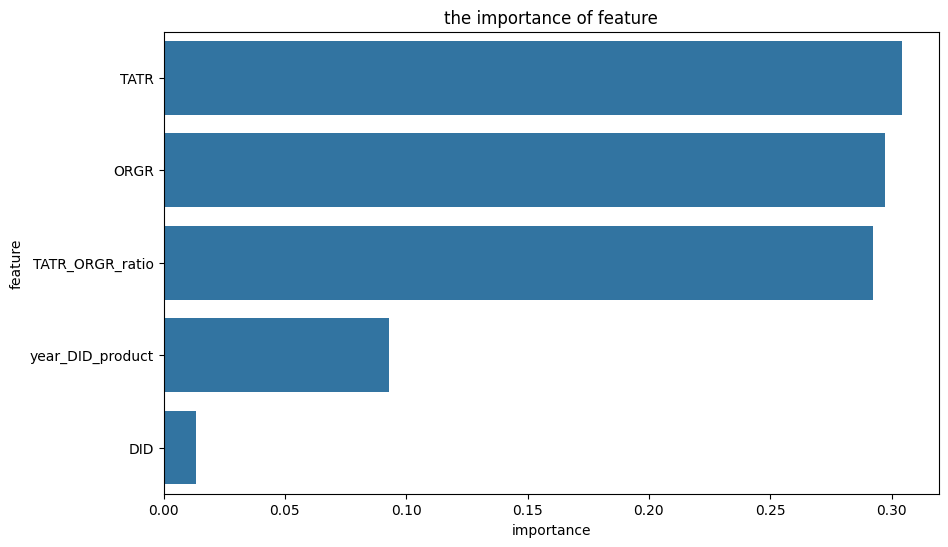

In [29]:
def plot_feature_importance(model, features):
    feature_importances = model.feature_importances_
    feature_names = features.columns
    
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importances
    }).sort_values(by='importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='importance', y='feature', data=importance_df)
    plt.title('the importance of feature')
    plt.show()

plot_feature_importance(rf_model_new, X_new)


This graph shows the importance of different features in a model. The x-axis represents the importance of the features, and the y-axis lists the feature names.
From the graph, I can observe the following:
TATR, ORGR, and TATR_ORGR_ratio have higher importance scores, indicating they have a greater influence on the model.
year_DID_product and DID have lower importance scores, suggesting they have less influence on the model.

conclusion

1. Comparison between the perfomance of RF and AdaBoost:

   Random Forest and AdaBoost behave differently with different parameter settings

   Random forests generally perform better when dealing with high-dimensional data

   AdaBoost is more sensitive to outliers, but may be more accurate in some cases

2. The impact of feature engineering:
   
   Removing certain features may slow down model performance
   
   Adding new features, such as ratios and products, may improve model performance
   
   Feature importance analysis helps identify key features

3. The impact of parameter adjustments:
   
   Increasing n_estimators generally improves performance, but increases compute costs
   
   max_depth and min_samples_split need balance model complexity with the risk of overfitting
   
   AdaBoost's learning_rate affects the learning speed and generalization ability of the model

In this section, I employed the Random Forest model and the AdaBoost model to train and test the data. Adjusting parameters and performing feature engineering were found to significantly influence the model's performance. The most challenging aspect of this phase was correctly implementing the code and effectively visualizing the results. After multiple iterations of experimentation, I ultimately successfully completed this project.

In this project, I utilised chatgpt to assist with various aspects of process, for example I used it to help generate code and debug bugs